In [1]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from rltesting.utils.torch_utils import EarlyStopping
from fvd_models import Encoder, Decoder, AEVAE
import numpy as np
import torch
import skdim
import os
from tiles import *

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy() 
framestack = 2
latent_dim = 512
obs_shape = 64
data_steps = 100000
num_epochs = 50
steps_per_epoch = 200
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
# env = DomainRandomization(env, {"LINK_LENGTH_1": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0]), "LINK_LENGTH_2": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0])})
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))

In [2]:
obs, _ = env.reset()

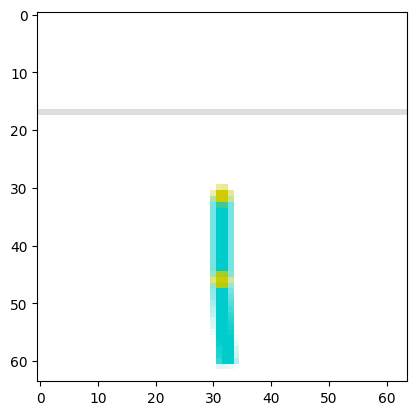

In [3]:
plt.imshow(obs[:, :, :3] / 255)

In [4]:
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)
filepath = "testing_buffer.npz"
if os.path.isfile(filepath):
  buffer.load(filepath)
else:
  samples = random_sample_single_env(env, num_steps=data_steps)
  for i in range(data_steps):
      buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())
  buffer.save(filepath=filepath)

In [5]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)
early_stop = EarlyStopping(patience=5)

In [6]:
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        reconstruction = decoder(latent)
        loss = torch.nn.functional.mse_loss(reconstruction, obs)          
        loss.backward()
        opt.step()
        opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    if early_stop(to_numpy(loss)):
      break
    scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)

2000
4000
6000
8000
10000


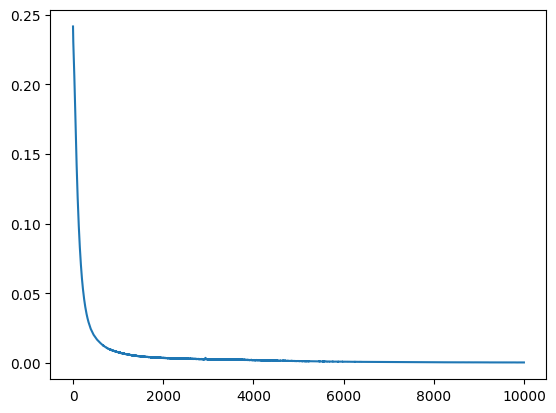

In [7]:
plt.plot(losses)

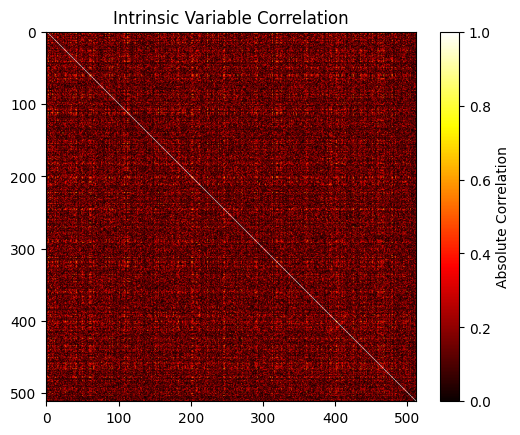

In [8]:
num_samples = 2048
with torch.no_grad():
    samples_ = buffer.sample(num_samples)
    obs = (torch.tensor(samples_[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs).cpu().numpy()

corr = np.corrcoef(latent, rowvar=False)
plt.imshow(np.abs(corr), cmap="hot", vmin=0, vmax=1)
plt.colorbar(label="Absolute Correlation")
plt.title("Intrinsic Variable Correlation")
plt.show()

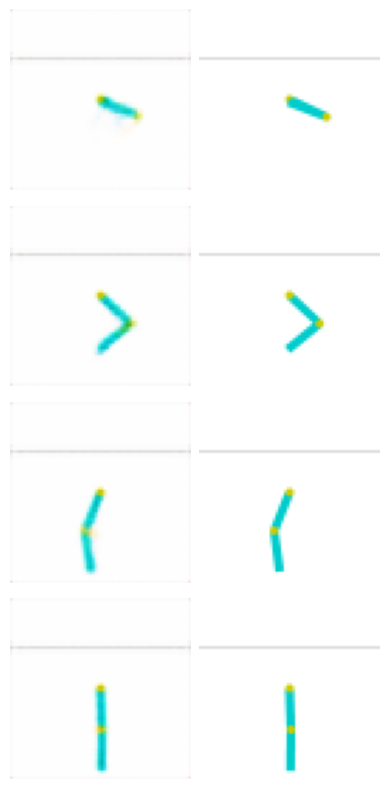

In [9]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
fig.savefig("direct_dim.png")

In [10]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 5.110452119982287 +- 0.04710967118307841
Image ID: 6.424109617994835 +- 0.06006214043851998


4000
8000
12000
16000
20000


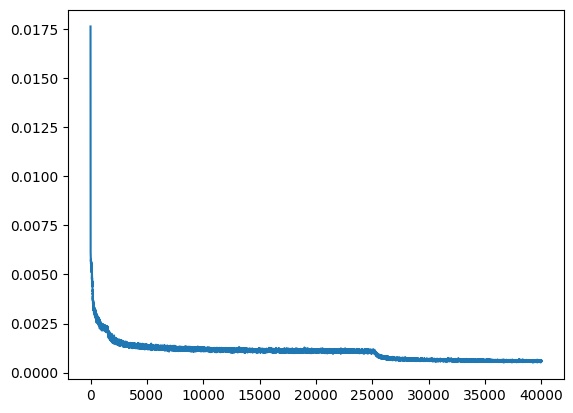

In [11]:
plt.close('all')
%matplotlib inline
intrinsic_dim = round(np.mean(latent_ID))
penalty_coef = 1e-4
double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)
int_scheduler = torch.optim.lr_scheduler.ExponentialLR(int_opt, gamma=0.99)
penalty_anneal = np.linspace(0, 1, num_epochs) ** 0.25 * penalty_coef
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(4 * steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        loss = double_autoencoder.reconstruction_loss(obs, penalty_anneal[num_epochs-1])
        loss.backward()
        int_opt.step()
        int_opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    int_scheduler.step()
    if i % 10 == 0:
        print(i * 2 * steps_per_epoch)
plt.plot(losses)

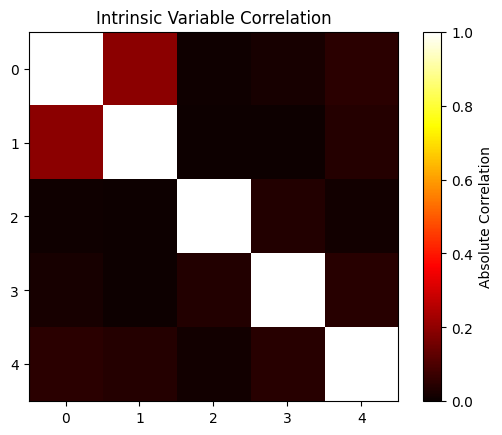

In [12]:
plt.close('all')
%matplotlib inline
num_samples = 2048
with torch.no_grad():
    samples = buffer.sample(num_samples)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    intrinsic = double_autoencoder.double_encode(obs).cpu().numpy()

corr = np.corrcoef(intrinsic, rowvar=False)
plt.imshow(np.abs(corr), cmap="hot", vmin=0, vmax=1)
plt.colorbar(label="Absolute Correlation")
plt.title("Intrinsic Variable Correlation")
plt.show()

In [13]:
# ---- Tile coding + Q-learning setup ---- #
num_actions = env.action_space.n

# Collect a large batch to estimate ranges
with torch.no_grad():
    range_samples = buffer.sample(10_000)
    range_obs = (torch.tensor(range_samples[0]).float().transpose(-3, -1) / 255).cuda()
    all_intrinsic = to_numpy(double_autoencoder.double_encode(range_obs))

num_tiles_per_dim = 3
num_tilings = max(16, 4 * intrinsic_dim)  # at least 4x num floats, power of 2
iht_size = (num_tiles_per_dim + 1) ** intrinsic_dim * num_tilings * num_actions
iht_size = max(iht_size, 4096)
iht_size = min(iht_size, 500000)


mins = all_intrinsic.min(axis=0)
maxs = all_intrinsic.max(axis=0)
ranges = maxs - mins
ranges[ranges == 0] = 1.0
buf = 0.02 * ranges
mins = mins - buf
ranges = ranges + 2 * buf
scale = num_tiles_per_dim / ranges

iht = IHT(iht_size)
w = np.zeros(iht_size)
alpha = 0.1 / num_tilings
gamma = 1.0
epsilon_start = 1.0
epsilon_end = 0.05
num_episodes = 500

means = all_intrinsic.mean(axis=0)
stds = all_intrinsic.std(axis=0)
stds[stds == 0] = 1.0

def encode_obs(obs):
    with torch.no_grad():
        t = (torch.tensor(obs).unsqueeze(0).float().transpose(-3, -1) / 255).cuda()
        raw = to_numpy(double_autoencoder.double_encode_deterministic(t)).squeeze()
        return (raw - means) / stds

def get_tiles(state, action):
    scaled = ((state - mins) * scale).tolist()
    return tiles(iht, num_tilings, scaled, ints=[action])

def Q(state, action):
    return np.sum(w[get_tiles(state, action)])

def pick_action(state, eps):
    if np.random.random() < eps:
        return np.random.randint(num_actions)
    qs = [Q(state, a) for a in range(num_actions)]
    return np.argmax(qs)

print(f"Intrinsic dim: {intrinsic_dim}")
print(f"Num tilings: {num_tilings}")
print(f"IHT size: {iht_size}")
print(f"Scale: {scale}")
print(f"Mins: {mins}")
print(f"Maxs: {maxs}")

Intrinsic dim: 5
Num tilings: 20
IHT size: 61440
Scale: [0.31946063 0.33759308 0.34156963 0.31549856 0.40497956]
Mins: [-5.031653  -4.0701237 -4.5118513 -3.898316  -3.8669252]
Maxs: [4.1785817 4.6454215 4.1022267 5.4275827 3.3983984]


In [14]:
# ---- Sanity check tile coding ---- #
print("=== Tile Coding Sanity Check ===\n")

# 1. Same state, same action -> same tiles
test_state = all_intrinsic[0]
t1 = get_tiles(test_state, 0)
t2 = get_tiles(test_state, 0)
print(f"Same (state, action) gives same tiles: {t1 == t2}")

# 2. Same state, different actions -> completely different tiles
tiles_by_action = [get_tiles(test_state, a) for a in range(num_actions)]
for a1 in range(num_actions):
    for a2 in range(a1 + 1, num_actions):
        overlap = set(tiles_by_action[a1]) & set(tiles_by_action[a2])
        print(f"Action {a1} vs {a2} overlap: {len(overlap)} tiles (should be 0)")

# 3. Nearby states -> share some tiles
s1 = all_intrinsic[0]
# find nearest neighbor
dists = np.linalg.norm(all_intrinsic[1:] - s1, axis=1)
s2 = all_intrinsic[1 + np.argmin(dists)]
t_s1 = get_tiles(s1, 0)
t_s2 = get_tiles(s2, 0)
shared = len(set(t_s1) & set(t_s2))
print(f"\nNearest neighbor dist: {np.min(dists):.4f}")
print(f"Shared tiles (nearby): {shared}/{num_tilings}")

# 4. Far apart states -> no shared tiles
s_far = all_intrinsic[np.argmax(dists)]
t_far = get_tiles(s_far, 0)
shared_far = len(set(t_s1) & set(t_far))
print(f"Farthest point dist:   {np.max(dists):.4f}")
print(f"Shared tiles (far):    {shared_far}/{num_tilings} (should be 0)")

# 5. Check scaled range and tile counts
print(f"\n--- Scaling ---")
print(f"Intrinsic dim: {intrinsic_dim}")
print(f"Scaled min:  {((all_intrinsic.min(0) - mins) * scale).round(2)}")
print(f"Scaled max:  {((all_intrinsic.max(0) - mins) * scale).round(2)}")
print(f"Expected ~[0.something, {num_tiles_per_dim} - something] per dim")

# 6. Tile index stats
print(f"\n--- IHT usage ---")
print(f"Tiles per call: {num_tilings}")
print(f"Sample indices:  {t_s1}")
print(f"Index range:     [{min(t_s1)}, {max(t_s1)}]")
print(f"IHT count:       {iht.count()}")
print(f"IHT size:        {iht.size}")
print(f"IHT full:        {iht.fullp()}")

# 7. Q values before training (should all be ~0)
qs = [Q(test_state, a) for a in range(num_actions)]
print(f"\nQ-values before training: {[round(q, 4) for q in qs]} (should be ~0)")

=== Tile Coding Sanity Check ===

Same (state, action) gives same tiles: True
Action 0 vs 1 overlap: 0 tiles (should be 0)
Action 0 vs 2 overlap: 0 tiles (should be 0)
Action 1 vs 2 overlap: 0 tiles (should be 0)

Nearest neighbor dist: 0.8159
Shared tiles (nearby): 10/20
Farthest point dist:   9.1009
Shared tiles (far):    0/20 (should be 0)

--- Scaling ---
Intrinsic dim: 5
Scaled min:  [0.06 0.06 0.06 0.06 0.06]
Scaled max:  [2.94 2.94 2.94 2.94 2.94]
Expected ~[0.something, 3 - something] per dim

--- IHT usage ---
Tiles per call: 20
Sample indices:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Index range:     [0, 19]
IHT count:       90
IHT size:        61440
IHT full:        False

Q-values before training: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] (should be ~0)


Episode   50 | Avg Return (last 50):  -492.1 | Epsilon: 0.891 | IHT used: 28310
Episode  100 | Avg Return (last 50):  -487.9 | Epsilon: 0.780 | IHT used: 48410
Episode  150 | Avg Return (last 50):  -477.1 | Epsilon: 0.669 | IHT used: 62166
Episode  200 | Avg Return (last 50):  -406.8 | Epsilon: 0.558 | IHT used: 73373
Episode  250 | Avg Return (last 50):  -356.9 | Epsilon: 0.447 | IHT used: 83302
Episode  300 | Avg Return (last 50):  -286.4 | Epsilon: 0.336 | IHT used: 90712
Episode  350 | Avg Return (last 50):  -241.6 | Epsilon: 0.224 | IHT used: 96930
IHT full, starting to allow collisions
Episode  400 | Avg Return (last 50):  -175.4 | Epsilon: 0.113 | IHT used: 100000
Episode  450 | Avg Return (last 50):  -146.4 | Epsilon: 0.050 | IHT used: 100000
Episode  500 | Avg Return (last 50):  -160.3 | Epsilon: 0.050 | IHT used: 100000
Episode  550 | Avg Return (last 50):  -153.6 | Epsilon: 0.050 | IHT used: 100000
Episode  600 | Avg Return (last 50):  -160.3 | Epsilon: 0.050 | IHT used: 100

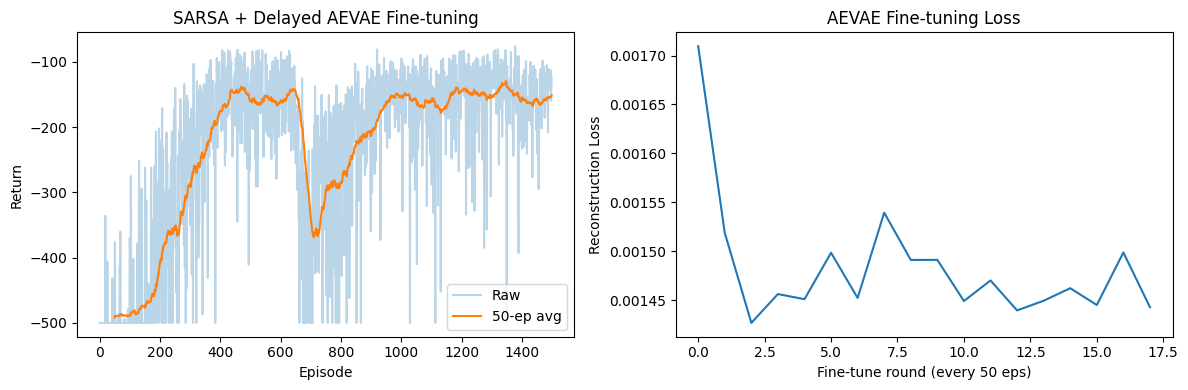

In [15]:
# ---- SARSA with delayed AEVAE fine-tuning ---- #
import copy

# Copy the original model so we can rerun this cell
aevae = copy.deepcopy(double_autoencoder)

num_tiles_per_dim = 3
iht = IHT(100000)
w = np.zeros(100000)
alpha = 0.05 / num_tilings
gamma = 1.0
num_episodes = 1500

# Fine-tuning setup
finetune_opt = torch.optim.Adam(aevae.parameters(), 1e-5)
finetune_every = 50
finetune_steps = 30
finetune_batch = 128
finetune_after = 600  # freeze until SARSA converges

# Online buffer
online_obs = []
max_online = 50000

# Initial scaling
with torch.no_grad():
    range_samples = buffer.sample(min(10000, buffer.size))
    range_obs = (torch.tensor(range_samples[0]).float().transpose(-3, -1) / 255).cuda()
    all_intrinsic = to_numpy(aevae.double_encode_deterministic(range_obs))

means = all_intrinsic.mean(axis=0)
stds = all_intrinsic.std(axis=0)
stds[stds == 0] = 1.0
mins = np.full(intrinsic_dim, -3.0)
scale = np.full(intrinsic_dim, num_tiles_per_dim / 6.0)

def encode_obs(obs):
    with torch.no_grad():
        t = (torch.tensor(obs).unsqueeze(0).float().transpose(-3, -1) / 255).cuda()
        raw = to_numpy(aevae.double_encode_deterministic(t)).squeeze()
        return (raw - means) / stds

def get_tiles(state, action):
    scaled = ((state - mins) * scale).tolist()
    return tiles(iht, num_tilings, scaled, ints=[action])

def Q(state, action):
    return np.sum(w[get_tiles(state, action)])

def pick_action(state, eps):
    if np.random.random() < eps:
        return np.random.randint(num_actions)
    return max(range(num_actions), key=lambda a: Q(state, a))

def finetune_aevae():
    if len(online_obs) < finetune_batch:
        return 0.0
    total_loss = 0
    for _ in range(finetune_steps):
        idx = np.random.choice(len(online_obs), finetune_batch, replace=False)
        batch = np.stack([online_obs[i] for i in idx])
        obs_t = (torch.tensor(batch).float().transpose(-3, -1) / 255).cuda()
        loss = aevae.reconstruction_loss(obs_t, penalty_coef)
        loss.backward()
        finetune_opt.step()
        finetune_opt.zero_grad()
        total_loss += loss.item()
    return total_loss / finetune_steps

def recompute_stats():
    if len(online_obs) < 200:
        return means, stds
    with torch.no_grad():
        idx = np.random.choice(len(online_obs), min(5000, len(online_obs)), replace=False)
        batch = np.stack([online_obs[i] for i in idx])
        t = (torch.tensor(batch).float().transpose(-3, -1) / 255).cuda()
        z = to_numpy(aevae.double_encode_deterministic(t))
    return z.mean(axis=0), np.maximum(z.std(axis=0), 1e-6)

# ---- Training loop ---- #
returns = []
ft_losses = []

for ep in range(num_episodes):
    epsilon = max(0.05, 1.0 - ep / (0.3 * num_episodes))

    obs, _ = env.reset()
    S = encode_obs(obs)
    A = pick_action(S, epsilon)
    total_reward = 0

    while True:
        obs_next, R, terminated, truncated, _ = env.step(A)
        done = terminated or truncated
        total_reward += R

        online_obs.append(obs_next)
        if len(online_obs) > max_online:
            online_obs.pop(0)

        if done:
            active = get_tiles(S, A)
            w[active] += alpha * (R - np.sum(w[active]))
            break

        S_next = encode_obs(obs_next)
        A_next = pick_action(S_next, epsilon)

        active = get_tiles(S, A)
        q_sa = np.sum(w[active])
        q_next = np.sum(w[get_tiles(S_next, A_next)])
        w[active] += alpha * (R + gamma * q_next - q_sa)

        S, A = S_next, A_next
        obs = obs_next

    returns.append(total_reward)

    # Fine-tune only after SARSA has converged
    if (ep + 1) % finetune_every == 0 and ep >= finetune_after:
        ft_loss = finetune_aevae()
        means, stds = recompute_stats()
        ft_losses.append(ft_loss)

    if (ep + 1) % 50 == 0:
        avg = np.mean(returns[-50:])
        ft_str = f" | FT loss: {ft_losses[-1]:.5f}" if ft_losses else ""
        print(f"Episode {ep+1:4d} | Avg Return (last 50): {avg:7.1f} | "
              f"Epsilon: {epsilon:.3f} | IHT used: {iht.count()}{ft_str}")

# ---- Plot ---- #
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
window = 50
smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')
axes[0].plot(returns, alpha=0.3, label='Raw')
axes[0].plot(range(window-1, len(returns)), smoothed, label=f'{window}-ep avg')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return')
axes[0].set_title('SARSA + Delayed AEVAE Fine-tuning'); axes[0].legend()

if ft_losses:
    axes[1].plot(ft_losses)
    axes[1].set_xlabel(f'Fine-tune round (every {finetune_every} eps)')
    axes[1].set_ylabel('Reconstruction Loss')
    axes[1].set_title('AEVAE Fine-tuning Loss')
plt.tight_layout(); plt.show()

Episode   25 | Avg Return (last 25):  -490.0 | Epsilon: 0.931 | IHT used: 54774
IHT full, starting to allow collisions
Episode   50 | Avg Return (last 25):  -495.2 | Epsilon: 0.860 | IHT used: 65536
Episode   75 | Avg Return (last 25):  -470.9 | Epsilon: 0.789 | IHT used: 65536
Episode  100 | Avg Return (last 25):  -446.6 | Epsilon: 0.717 | IHT used: 65536
Episode  125 | Avg Return (last 25):  -406.9 | Epsilon: 0.646 | IHT used: 65536
Episode  150 | Avg Return (last 25):  -405.4 | Epsilon: 0.574 | IHT used: 65536
Episode  175 | Avg Return (last 25):  -378.0 | Epsilon: 0.503 | IHT used: 65536
Episode  200 | Avg Return (last 25):  -347.6 | Epsilon: 0.431 | IHT used: 65536
Episode  225 | Avg Return (last 25):  -335.4 | Epsilon: 0.360 | IHT used: 65536
Episode  250 | Avg Return (last 25):  -317.3 | Epsilon: 0.289 | IHT used: 65536
Episode  275 | Avg Return (last 25):  -318.0 | Epsilon: 0.217 | IHT used: 65536
Episode  300 | Avg Return (last 25):  -293.2 | Epsilon: 0.146 | IHT used: 65536
E

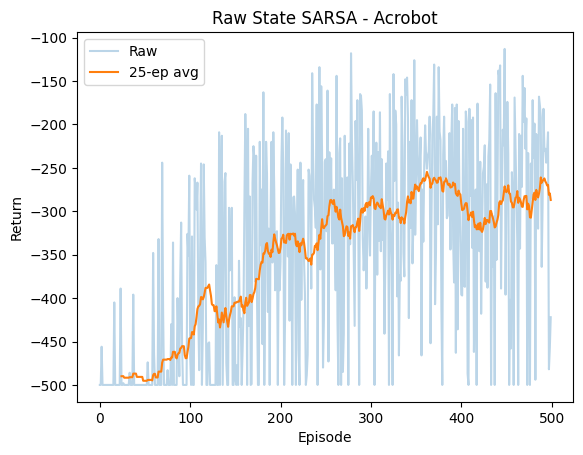

In [16]:
# ---- Sanity check: SARSA on raw Acrobot state ---- #
# Acrobot obs is 6-dim: [cos(t1), sin(t1), cos(t2), sin(t2), dt1, dt2]
raw_env = gym.make('Acrobot-v1')
raw_num_actions = raw_env.action_space.n

raw_iht = IHT(65536)
raw_num_tilings = 32  # 4 * 6 dims = 24, round up to 32
raw_w = np.zeros(65536)
raw_alpha = 0.1 / raw_num_tilings

# Acrobot obs ranges: cos/sin in [-1,1], velocities in [-12.57, 12.57]
raw_scales = np.array([
    5.0 / 2,   # cos(t1): [-1,1] -> [0,5]
    5.0 / 2,   # sin(t1)
    5.0 / 2,   # cos(t2)
    5.0 / 2,   # sin(t2)
    5.0 / 25,  # dt1: [-12.57,12.57] -> [0,5]
    5.0 / 25,  # dt2
])
raw_offsets = np.array([1, 1, 1, 1, 12.57, 12.57])

def raw_get_tiles(state, action):
    scaled = ((state + raw_offsets) * raw_scales).tolist()
    return tiles(raw_iht, raw_num_tilings, scaled, ints=[action])

def raw_Q(state, action):
    return np.sum(raw_w[raw_get_tiles(state, action)])

def raw_pick_action(state, eps):
    if np.random.random() < eps:
        return np.random.randint(raw_num_actions)
    return max(range(raw_num_actions), key=lambda a: raw_Q(state, a))

raw_returns = []
for ep in range(500):
    eps = max(0.05, 1.0 - ep / 350)
    obs, _ = raw_env.reset()
    S = np.array(obs)
    A = raw_pick_action(S, eps)
    total_reward = 0

    while True:
        obs_next, R, terminated, truncated, _ = raw_env.step(A)
        done = terminated or truncated
        total_reward += R

        if done:
            active = raw_get_tiles(S, A)
            raw_w[active] += raw_alpha * (R - np.sum(raw_w[active]))
            break

        S_next = np.array(obs_next)
        A_next = raw_pick_action(S_next, eps)
        active = raw_get_tiles(S, A)
        q_sa = np.sum(raw_w[active])
        q_next = np.sum(raw_w[raw_get_tiles(S_next, A_next)])
        raw_w[active] += raw_alpha * (R + q_next - q_sa)

        S, A = S_next, A_next

    raw_returns.append(total_reward)
    if (ep + 1) % 25 == 0:
        print(f"Episode {ep+1:4d} | Avg Return (last 25): {np.mean(raw_returns[-25:]):7.1f} | "
              f"Epsilon: {eps:.3f} | IHT used: {raw_iht.count()}")

window = 25
smoothed = np.convolve(raw_returns, np.ones(window)/window, mode='valid')
plt.plot(raw_returns, alpha=0.3, label='Raw')
plt.plot(range(window-1, len(raw_returns)), smoothed, label=f'{window}-ep avg')
plt.xlabel('Episode'); plt.ylabel('Return'); plt.title('Raw State SARSA - Acrobot')
plt.legend(); plt.show()